**Goal:** make `loss.backward()` ordinary. In L15 it was magic; here you build the exact engine
behind it in about eighty lines of plain Python -- a scalar **autograd** engine that records every
operation on a computational graph and runs the chain rule backward over it. You will check its
gradients against the chain rule by hand, against PyTorch (they agree to the last digit) and against
a numerical estimate, and then *train a real neural net with your own engine*. This lab reproduces
the core of **Andrej Karpathy's micrograd** (MIT License). Pairs with the concept note
[Backpropagation & Autodiff](l16_concept_backprop_autodiff.qmd).

> **Previously:** L15 -- Multilayer Perceptrons (we called backward() as a black box)  |  **Next:** L17 -- Training Deep Networks

> This page is the read-only view. To run the lab, open the notebook
> (`l16_lab_backprop_autodiff.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

A neural network is just a big mathematical expression: inputs and weights flow through additions,
multiplications, and activations to a single scalar loss. To train it we need the gradient of that
loss with respect to every weight. **Backpropagation is the chain rule run once backward over the
expression graph.** We will represent every number as a `Value` that remembers how it was made, give
each operation a rule for passing gradients to its inputs, and let one reverse sweep fill in every
gradient. Then we train a small network on the two-moons dataset using nothing but our engine.

## Setup

Two cells: the first installs, the second imports and seeds.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships numpy, scikit-learn, matplotlib and torch, so this is effectively a no-op there.
%pip install -q numpy scikit-learn matplotlib torch
# local, in a terminal (not in the notebook):  uv add numpy scikit-learn matplotlib torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS + SEEDS (safe to re-run without re-installing)
import math
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0); random.seed(1); np.random.seed(1)   # data + weights are reseeded in Step 4 too

## Step 1: Build the Autograd Engine

Each `Value` stores its number (`data`), a slot for its gradient (`grad`), and a `_backward`
closure that knows how to push this node's gradient to the inputs that made it -- using the
operation's **local derivative**. Note every `_backward` uses `+=`: a node that feeds several places
**accumulates** gradients (the multivariable chain rule).

| operation | local gradient(s) |
|---|---|
| `a + b` | 1 and 1 |
| `a * b` | `b` and `a` |
| `a ** k` | `k * a**(k-1)` |
| `relu(a)` | 1 if `a > 0` else 0 |
| `tanh(a)` | `1 - tanh(a)**2` |

In [3]:
class Value:
    """A scalar that remembers how it was produced, so .backward() can fill in .grad."""

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None     # how to push grad to inputs
        self._prev = set(_children)        # the nodes that produced this one
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad          # d(a+b)/da = 1
            other.grad += out.grad         # d(a+b)/db = 1
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad   # d(a*b)/da = b
            other.grad += self.data * out.grad   # d(a*b)/db = a
        out._backward = _backward
        return out

    def __pow__(self, other):
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t * t) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # 1) topological order: a node comes after every node it depends on
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        # 2) seed dL/dL = 1, then push gradients backward through the graph
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    # convenience so ordinary Python arithmetic "just works"
    def __neg__(self):        return self * -1
    def __radd__(self, o):    return self + o
    def __sub__(self, o):     return self + (-o)
    def __rsub__(self, o):    return o + (-self)
    def __rmul__(self, o):    return self * o
    def __truediv__(self, o): return self * o ** -1
    def __repr__(self):       return f"Value(data={self.data}, grad={self.grad})"

That is the entire engine. The `backward()` method is the whole of backpropagation: order the graph
so every node comes after the nodes it depends on, seed the final gradient to 1, and sweep in reverse
so each node's gradient is complete before it pushes to its inputs.

## Step 2: Verify It

Take `L = (a*b + c) * f` with `a=2, b=-3, c=10, f=-2`. By hand `L = (-6+10)*-2 = -8`, and e.g.
`dL/da = f*b = (-2)(-3) = 6`. Run the engine and read off every gradient at once:

In [4]:
a = Value(2.0); b = Value(-3.0); c = Value(10.0); f = Value(-2.0)
L = (a*b + c) * f
L.backward()
print(f"L = {L.data}")
print(f"dL/da={a.grad}  dL/db={b.grad}  dL/dc={c.grad}  dL/df={f.grad}")

L = -8.0
dL/da=6.0  dL/db=-4.0  dL/dc=-2.0  dL/df=4.0


~~~text
L = -8.0
dL/da=6.0  dL/db=-4.0  dL/dc=-2.0  dL/df=4.0
~~~

Now cross-check the identical graph in **PyTorch** -- the same reverse-mode algorithm, on tensors:

In [5]:
at = torch.tensor(2.0, requires_grad=True); bt = torch.tensor(-3.0, requires_grad=True)
ct = torch.tensor(10.0, requires_grad=True); ft = torch.tensor(-2.0, requires_grad=True)
Lt = ((at*bt) + ct) * ft
Lt.backward()
print(f"torch: dL/da={at.grad.item()}  dL/db={bt.grad.item()}  dL/dc={ct.grad.item()}  dL/df={ft.grad.item()}")

torch: dL/da=6.0  dL/db=-4.0  dL/dc=-2.0  dL/df=4.0


~~~text
torch: dL/da=6.0  dL/db=-4.0  dL/dc=-2.0  dL/df=4.0
~~~

Identical. Now a single neuron -- `n = x1*w1 + x2*w2 + b`, then `tanh` (the bias is chosen so the
gradients land on round numbers):

In [6]:
x1 = Value(2.0); x2 = Value(0.0); w1 = Value(-3.0); w2 = Value(1.0)
bias = Value(6.8813735870195432)
n = x1*w1 + x2*w2 + bias
o = n.tanh()
o.backward()
print(f"o = {o.data:.4f}")
print(f"dx1={x1.grad:.4f}  dw1={w1.grad:.4f}  dx2={x2.grad:.4f}  dw2={w2.grad:.4f}")

o = 0.7071
dx1=-1.5000  dw1=1.0000  dx2=0.5000  dw2=0.0000


~~~text
o = 0.7071
dx1=-1.5000  dw1=1.0000  dx2=0.5000  dw2=0.0000
~~~

## Step 3: Numerical Gradient Check -- completion problem

A third, independent check: nudge an input by a tiny `h` and measure how the output changes. The
**central difference** `(L(a+h) - L(a-h)) / (2h)` estimates `dL/da` without any calculus. Complete
the denominator:

In [7]:
# Uncomment and complete the central-difference estimate of dL/da at a = 2:
# def L_of_a(av):
#     a_, b_, c_, f_ = Value(av), Value(-3.0), Value(10.0), Value(-2.0)
#     return ((a_*b_ + c_) * f_).data
# h = 1e-6
# numerical = (L_of_a(2.0 + h) - L_of_a(2.0 - h)) / ____    # complete the denominator
# print(f"numerical dL/da = {numerical:.4f}   analytic = {a.grad}")

<details><summary>Expected Output</summary>

~~~text
numerical dL/da = 6.0000   analytic = 6.0
~~~

The blank is `(2 * h)`. The finite-difference estimate agrees with the engine's analytic gradient.
Numerical gradients are a great *check*, but useless for training: they need a separate forward pass
per parameter and lose precision. Backprop gets all gradients exactly in one backward pass.
</details>

## Step 4: Train a Net with Your Engine

A neural network is just a particular expression graph, so our engine can train one. Here are
`Neuron`, `Layer`, and `MLP` built on `Value` (micrograd's `nn`), then a training loop on the
two-moons data using a max-margin hinge loss (the SVM loss of L08) plus a tiny L2 penalty:

In [8]:
class Neuron:
    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)
        self.nonlin = nonlin
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)   # w . x + b
        return act.relu() if self.nonlin else act
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]
    def __call__(self, x):
        out = [nu(x) for nu in self.neurons]
        return out[0] if len(out) == 1 else out
    def parameters(self):
        return [p for nu in self.neurons for p in nu.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i != len(nouts)-1) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

In [9]:
from sklearn.datasets import make_moons
random.seed(1); np.random.seed(1)

X, y = make_moons(n_samples=100, noise=0.1, random_state=0)
y = y * 2 - 1                              # {0,1} -> {-1,+1} for the hinge loss

model = MLP(2, [16, 1])                     # 2 inputs -> 16 ReLU hidden -> 1 linear output
print(len(model.parameters()), "parameters")

for k in range(80):
    scores = [model(list(map(Value, row))) for row in X]               # forward
    data_loss = sum((1 + -yi*si).relu() for yi, si in zip(y, scores)) * (1.0/len(y))
    reg_loss = 1e-4 * sum((p*p for p in model.parameters()))
    loss = data_loss + reg_loss                                        # loss
    acc = sum((yi > 0) == (si.data > 0) for yi, si in zip(y, scores)) / len(y)
    model.zero_grad()                                                  # clear (grads accumulate)
    loss.backward()                                                    # backward: OUR engine
    lr = 1.0 - 0.9 * k / 80                                            # gentle decay (schedules -> L17)
    for p in model.parameters():
        p.data -= lr * p.grad                                          # plain gradient-descent step
    if k % 20 == 0 or k == 79:
        print(f"step {k:2d}  loss {loss.data:.4f}  acc {acc:.2%}")

65 parameters
step  0  loss 0.6821  acc 73.00%


step 20  loss 0.2208  acc 89.00%


step 40  loss 0.1866  acc 94.00%


step 60  loss 0.1612  acc 97.00%


step 79  loss 0.1481  acc 97.00%


~~~text
65 parameters
step  0  loss 0.6821  acc 73.00%
step 20  loss 0.2208  acc 89.00%
step 40  loss 0.1866  acc 94.00%
step 60  loss 0.1612  acc 97.00%
step 79  loss 0.1481  acc 97.00%
~~~

Our hand-built engine trained a 65-parameter network to **97%** on a non-linearly-separable problem
-- every gradient computed by the same `backward()` we wrote in Step 1. Plot the boundary it learned
(a coarse grid -- the scalar engine is slow over a mesh):

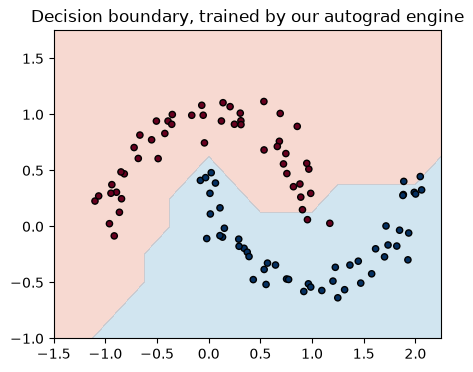

In [10]:
h = 0.25
xx, yy = np.meshgrid(np.arange(-1.5, 2.5, h), np.arange(-1.0, 2.0, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([model(list(map(Value, row))).data > 0 for row in grid]).reshape(xx.shape)
plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolors="k", s=20)
plt.title("Decision boundary, trained by our autograd engine")
plt.show()

Finally, the same neuron in **PyTorch autograd** -- the identical gradients (`dw = [1, 0]`,
`db = 0.5`), proving `loss.backward()` from L15 is exactly the engine you just built, vectorized:

In [11]:
xv = torch.tensor([2.0, 0.0])
wv = torch.tensor([-3.0, 1.0], requires_grad=True)
bv = torch.tensor(6.8813735870195432, requires_grad=True)
ov = torch.tanh((xv*wv).sum() + bv)
ov.backward()
print(f"torch neuron: o={ov.item():.4f}  dw=[{wv.grad[0]:.4f}, {wv.grad[1]:.4f}]  db={bv.grad.item():.4f}")

torch neuron: o=0.7071  dw=[1.0000, 0.0000]  db=0.5000


~~~text
torch neuron: o=0.7071  dw=[1.0000, 0.0000]  db=0.5000
~~~

## Your Turn

### Exercise 1 -- Add a `sigmoid` to the engine

Give `Value` a `sigmoid` method. The forward value is `1 / (1 + exp(-z))`; its local derivative is
`sig * (1 - sig)`. Attach it to the class, then check it against `torch.sigmoid` at `z = 0.5`.

**Hint:** mirror the `tanh` method; compute `s = 1/(1+math.exp(-self.data))` and accumulate `s*(1-s)*out.grad`.

In [12]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
Value: sigmoid=0.6225  grad=0.2350
torch: sigmoid=0.6225  grad=0.2350
~~~

The method mirrors `tanh`: compute `s = 1 / (1 + math.exp(-self.data))`, build the output `Value`,
and in its `_backward` accumulate `s * (1 - s) * out.grad`. Attach it with `Value.sigmoid = _sigmoid`.
The engine extends just like PyTorch: define an op's forward value and its local derivative, and
`backward()` composes it into the whole graph automatically.
</details>

### Exercise 2 -- Numerically check a network weight

Backprop computed gradients for all 65 weights at once -- but are the *network's* gradients right?
Recompute the loss and `backward()` at the trained weights, then numerically check the first weight:
perturb `model.parameters()[0].data` by `+/-1e-5`, recompute the loss each time, and compare the
finite-difference slope to that weight's `.grad`.

**Hint:** save `g = model.parameters()[0].grad`; perturb `.data` by `+h` and `-h`, recompute the loss both times, then `(L_plus - L_minus) / (2*h)`.

In [13]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
numerical 0.0037   analytic 0.0037
~~~

The finite-difference slope matches the gradient backprop produced for that weight -- the chain rule,
run backward through the whole network, is exactly right. This is how autograd engines are tested.
</details>

## Summary

- A `Value` records each operation and a `_backward` closure (its **local derivative**); `backward()`
  topologically sorts the graph, seeds `dL/dL = 1`, and sweeps in reverse. That is all of backprop.
- Gradients **accumulate** (`+=`) where a node fans out -- which is why a training loop calls
  `zero_grad()` every step.
- The engine matched the chain rule by hand, **PyTorch autograd to the last digit** (6 / -4 / -2 / 4),
  and a numerical check (6.0000); and it trained a 65-parameter MLP to 97% on two-moons.
- `loss.backward()` from L15 is exactly this engine, vectorized over tensors and written in C++/CUDA.
- Next (L17): now that gradients are demystified, how to train deep networks *well* -- initialization,
  optimizers, and regularization.